# Supply Chain Optimization Engine

Operations Research Scientist Showcase Project


## 1. Business Context

We solve a large transportation optimization problem with 15 plants, 120 warehouse demand zones, and 1,800 transportation lanes. 

The objective is to minimize total logistics cost while satisfying warehouse demand and respecting plant and route capacities.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ortools.linear_solver import pywraplp


## 2. Load Dataset


In [2]:
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

plants = pd.read_csv(DATA_DIR / 'plants.csv')
warehouses = pd.read_csv(DATA_DIR / 'warehouses.csv')
routes = pd.read_csv(DATA_DIR / 'transport_cost.csv')

print('Plants:', plants.shape)
print('Warehouses:', warehouses.shape)
print('Routes:', routes.shape)


Plants: (15, 10)
Warehouses: (120, 10)
Routes: (1800, 13)


In [3]:
plants.head()


,plant_id,plant,region,latitude,longitude,capacity,fixed_operating_cost,variable_handling_cost_per_unit,max_dispatch_routes,status
0,P001,Plant_Ahmedabad,West,23.0225,72.5714,31033,431932,2.83,27,Active
1,P002,Plant_Surat,West,21.1702,72.8311,22324,354886,4.01,42,Active
2,P003,Plant_Vadodara,West,22.3072,73.1812,16708,387498,5.90,43,Active
3,P004,Plant_Mumbai,West,19.0760,72.8777,19610,629365,2.25,43,Active
4,P005,Plant_Pune,West,18.5204,73.8567,30794,499041,2.82,40,Active


In [4]:
warehouses.head()


,warehouse_id,warehouse,city,region,latitude,longitude,demand,service_level_target,priority,status
0,W001,WH_Ahmedabad_Zone_1,Ahmedabad,West,23.0617,72.7401,2779,0.99,Low,Active
1,W002,WH_Ahmedabad_Zone_2,Ahmedabad,West,23.2070,72.7092,1655,0.96,Medium,Active
2,W003,WH_Ahmedabad_Zone_3,Ahmedabad,West,23.2086,72.6142,1537,0.96,Medium,Active
3,W004,WH_Ahmedabad_Zone_4,Ahmedabad,West,22.8523,72.7662,1692,0.93,Low,Active
4,W005,WH_Surat_Zone_1,Surat,West,20.9758,72.7106,2567,0.95,Medium,Active


In [5]:
routes.head()


,plant_id,plant,warehouse_id,warehouse,plant_region,warehouse_region,distance_km,cost_per_unit,lead_time_days,route_capacity,emission_kg_per_unit,route_risk_score,route_status
0,P001,Plant_Ahmedabad,W001,WH_Ahmedabad_Zone_1,West,West,17.8,5.39,1,5380,0.0025,3.26,Open
1,P001,Plant_Ahmedabad,W002,WH_Ahmedabad_Zone_2,West,West,24.9,5.09,1,2403,0.0040,3.60,Open
2,P001,Plant_Ahmedabad,W003,WH_Ahmedabad_Zone_3,West,West,21.2,5.95,1,3272,0.0034,4.60,Open
3,P001,Plant_Ahmedabad,W004,WH_Ahmedabad_Zone_4,West,West,27.5,5.16,1,2260,0.0036,1.61,Open
4,P001,Plant_Ahmedabad,W005,WH_Surat_Zone_1,West,West,228.0,6.47,1,3670,0.0504,1.21,Open


## 3. Feasibility Check


In [6]:
total_capacity = plants['capacity'].sum()
total_demand = warehouses['demand'].sum()
print('Total Capacity:', total_capacity)
print('Total Demand:', total_demand)
print('Capacity Buffer %:', round((total_capacity / total_demand - 1) * 100, 2))

assert total_capacity >= total_demand, 'Infeasible: total demand exceeds total capacity'


Total Capacity: 330297
Total Demand: 279911
Capacity Buffer %: 18.0


## 4. Mathematical Model

Decision variable: $x[i,j]$ = quantity shipped from plant i to warehouse j.

Objective: minimize total transportation cost.

Constraints:
- total shipment from each plant <= plant capacity
- total received by each warehouse = warehouse demand
- each route shipment <= route capacity
- $x[i,j] >= 0$


## 5. Solve Optimization Model


In [7]:
plant_ids = plants['plant_id'].astype(str).tolist()
warehouse_ids = warehouses['warehouse_id'].astype(str).tolist()

plants['plant_id'] = plants['plant_id'].astype(str)
warehouses['warehouse_id'] = warehouses['warehouse_id'].astype(str)
routes['plant_id'] = routes['plant_id'].astype(str)
routes['warehouse_id'] = routes['warehouse_id'].astype(str)

capacity = dict(zip(plants['plant_id'], plants['capacity']))
demand = dict(zip(warehouses['warehouse_id'], warehouses['demand']))
cost = {(r.plant_id, r.warehouse_id): r.cost_per_unit for r in routes.itertuples(index=False)}
route_cap = {(r.plant_id, r.warehouse_id): r.route_capacity for r in routes.itertuples(index=False)}

solver = pywraplp.Solver.CreateSolver('GLOP')
x = {}
for i in plant_ids:
    for j in warehouse_ids:
        x[(i,j)] = solver.NumVar(0, route_cap[(i,j)], f'x_{i}_{j}')

# Capacity constraints
for i in plant_ids:
    solver.Add(sum(x[(i,j)] for j in warehouse_ids) <= capacity[i])

# Demand constraints
for j in warehouse_ids:
    solver.Add(sum(x[(i,j)] for i in plant_ids) == demand[j])

# Objective
objective = solver.Objective()
for (i,j), var in x.items():
    objective.SetCoefficient(var, cost[(i,j)])
objective.SetMinimization()

status = solver.Solve()
print('Solver status:', status)
print('Optimal cost:', objective.Value())


Solver status: 0
Optimal cost: 2418060.27


## 6. Generate Output Tables


In [8]:
route_lookup = routes.set_index(['plant_id', 'warehouse_id']).to_dict('index')
plant_lookup = plants.set_index('plant_id').to_dict('index')
warehouse_lookup = warehouses.set_index('warehouse_id').to_dict('index')

shipments = []
for (i,j), var in x.items():
    qty = var.solution_value()
    if qty > 1e-6:
        r = route_lookup[(i,j)]
        p = plant_lookup[i]
        w = warehouse_lookup[j]
        shipments.append({
            'plant_id': i,
            'plant': p['plant'],
            'plant_region': p['region'],
            'warehouse_id': j,
            'warehouse': w['warehouse'],
            'warehouse_region': w['region'],
            'quantity_shipped': round(qty, 2),
            'cost_per_unit': r['cost_per_unit'],
            'total_route_cost': round(qty * r['cost_per_unit'], 2),
            'distance_km': r['distance_km'],
            'lead_time_days': r['lead_time_days'],
            'emission_kg_per_unit': r['emission_kg_per_unit'],
            'total_emission_kg': round(qty * r['emission_kg_per_unit'], 2),
            'route_risk_score': r['route_risk_score']
        })

shipments_df = pd.DataFrame(shipments)
shipments_df.head(10)


,plant_id,plant,plant_region,warehouse_id,warehouse,warehouse_region,quantity_shipped,cost_per_unit,total_route_cost,distance_km,lead_time_days,emission_kg_per_unit,total_emission_kg,route_risk_score
0,P001,Plant_Ahmedabad,West,W001,WH_Ahmedabad_Zone_1,West,2779.0,5.39,14978.81,17.8,1,0.0025,6.95,3.26
1,P001,Plant_Ahmedabad,West,W002,WH_Ahmedabad_Zone_2,West,1655.0,5.09,8423.95,24.9,1,0.0040,6.62,3.60
2,P001,Plant_Ahmedabad,West,W003,WH_Ahmedabad_Zone_3,West,1537.0,5.95,9145.15,21.2,1,0.0034,5.23,4.60
3,P001,Plant_Ahmedabad,West,W004,WH_Ahmedabad_Zone_4,West,1692.0,5.16,8730.72,27.5,1,0.0036,6.09,1.61
4,P001,Plant_Ahmedabad,West,W009,WH_Rajkot_Zone_1,West,2770.0,6.81,18863.70,184.7,1,0.0266,73.68,3.74
5,P001,Plant_Ahmedabad,West,W010,WH_Rajkot_Zone_2,West,1702.0,5.40,9190.80,200.7,1,0.0432,73.53,1.43
6,P001,Plant_Ahmedabad,West,W012,WH_Rajkot_Zone_4,West,463.0,8.33,3856.79,190.5,1,0.0266,12.32,4.26
7,P001,Plant_Ahmedabad,West,W026,WH_Delhi_Zone_2,North,3650.0,12.67,46245.50,760.8,2,0.1443,526.70,3.53
8,P001,Plant_Ahmedabad,West,W027,WH_Delhi_Zone_3,North,1688.0,11.30,19074.40,782.8,2,0.1748,295.06,3.14
9,P001,Plant_Ahmedabad,West,W028,WH_Delhi_Zone_4,North,371.0,12.77,4737.67,776.2,2,0.1768,65.59,1.82


In [9]:
plant_usage = shipments_df.groupby(['plant_id','plant','plant_region'], as_index=False).agg(
    total_shipped=('quantity_shipped','sum'),
    total_cost=('total_route_cost','sum'),
    total_emission_kg=('total_emission_kg','sum')
)
plant_usage = plant_usage.merge(plants[['plant_id','capacity']], on='plant_id', how='left')
plant_usage['utilization_percent'] = round(plant_usage['total_shipped'] / plant_usage['capacity'] * 100, 2)
plant_usage['unused_capacity'] = round(plant_usage['capacity'] - plant_usage['total_shipped'], 2)
plant_usage.sort_values('utilization_percent', ascending=False).head()


,plant_id,plant,plant_region,total_shipped,total_cost,total_emission_kg,capacity,utilization_percent,unused_capacity
0,P001,Plant_Ahmedabad,West,31033.0,282000.95,2289.32,31033,100.0,0.0
3,P004,Plant_Mumbai,West,19610.0,139224.83,1038.44,19610,100.0,0.0
5,P006,Plant_Delhi,North,26499.0,202997.62,546.54,26499,100.0,0.0
6,P007,Plant_Jaipur,North,19867.0,150009.98,684.64,19867,100.0,0.0
7,P008,Plant_Lucknow,North,15457.0,102978.41,176.54,15457,100.0,0.0


In [10]:
demand_fulfillment = shipments_df.groupby(['warehouse_id','warehouse','warehouse_region'], as_index=False).agg(
    total_received=('quantity_shipped','sum'),
    total_inbound_cost=('total_route_cost','sum'),
    avg_lead_time_days=('lead_time_days','mean')
)
demand_fulfillment = demand_fulfillment.merge(
    warehouses[['warehouse_id','demand','priority','service_level_target']],
    on='warehouse_id', how='left'
)
demand_fulfillment['fulfillment_gap'] = round(demand_fulfillment['demand'] - demand_fulfillment['total_received'], 2)
demand_fulfillment['fulfillment_percent'] = round(demand_fulfillment['total_received'] / demand_fulfillment['demand'] * 100, 2)
demand_fulfillment.head()


,warehouse_id,warehouse,warehouse_region,total_received,total_inbound_cost,avg_lead_time_days,demand,priority,service_level_target,fulfillment_gap,fulfillment_percent
0,W001,WH_Ahmedabad_Zone_1,West,2779.0,14978.81,1.0,2779,Low,0.99,0.0,100.0
1,W002,WH_Ahmedabad_Zone_2,West,1655.0,8423.95,1.0,1655,Medium,0.96,0.0,100.0
2,W003,WH_Ahmedabad_Zone_3,West,1537.0,9145.15,1.0,1537,Medium,0.96,0.0,100.0
3,W004,WH_Ahmedabad_Zone_4,West,1692.0,8730.72,1.0,1692,Low,0.93,0.0,100.0
4,W005,WH_Surat_Zone_1,West,2567.0,18174.36,1.0,2567,Medium,0.95,0.0,100.0


In [11]:
summary = pd.DataFrame([{
    'minimum_total_transportation_cost': round(objective.Value(), 2),
    'total_quantity_shipped': round(shipments_df['quantity_shipped'].sum(), 2),
    'total_demand_fulfilled': round(demand_fulfillment['total_received'].sum(), 2),
    'total_emission_kg': round(shipments_df['total_emission_kg'].sum(), 2),
    'active_routes_used': len(shipments_df),
    'plants_used': shipments_df['plant_id'].nunique(),
    'warehouses_served': shipments_df['warehouse_id'].nunique(),
    'average_cost_per_unit': round(objective.Value() / shipments_df['quantity_shipped'].sum(), 4)
}])
summary


,minimum_total_transportation_cost,total_quantity_shipped,total_demand_fulfilled,total_emission_kg,active_routes_used,plants_used,warehouses_served,average_cost_per_unit
0,2418060.27,279911.0,279911.0,13009.75,165,15,120,8.6387


## 7. Save Outputs


In [12]:
shipments_df.to_csv(OUTPUT_DIR / 'optimal_shipment_plan.csv', index=False)
plant_usage.to_csv(OUTPUT_DIR / 'capacity_utilization.csv', index=False)
demand_fulfillment.to_csv(OUTPUT_DIR / 'demand_fulfillment.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'cost_summary.csv', index=False)
print('Output files saved to:', OUTPUT_DIR)


Output files saved to: ..\outputs


## 8. Basic Visuals for Explanation


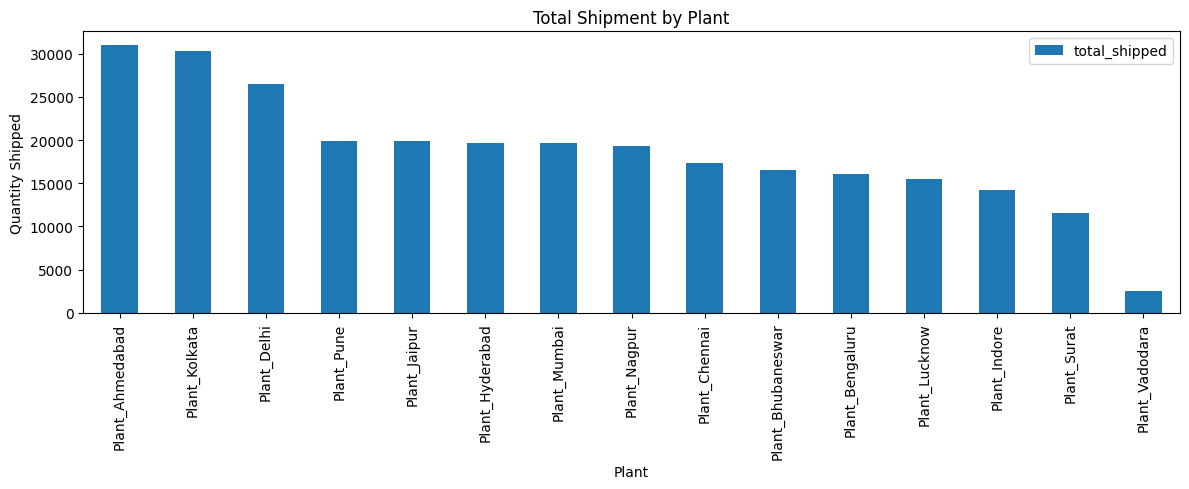

In [13]:
plant_usage.sort_values('total_shipped', ascending=False).plot(
    x='plant', y='total_shipped', kind='bar', figsize=(12,5), title='Total Shipment by Plant'
)
plt.xlabel('Plant')
plt.ylabel('Quantity Shipped')
plt.tight_layout()
plt.show()


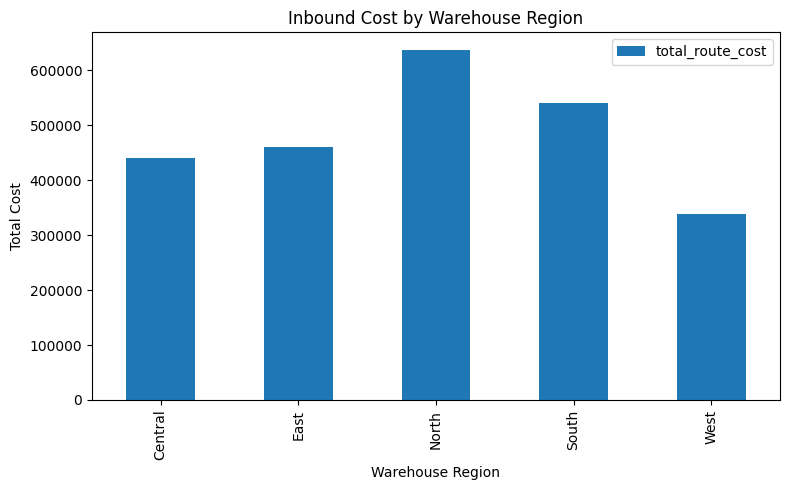

In [14]:
region_cost = shipments_df.groupby('warehouse_region', as_index=False)['total_route_cost'].sum()
region_cost.plot(x='warehouse_region', y='total_route_cost', kind='bar', figsize=(8,5), title='Inbound Cost by Warehouse Region')
plt.xlabel('Warehouse Region')
plt.ylabel('Total Cost')
plt.tight_layout()
plt.show()


## 9. Explanation

This project converts a classical OR transportation model into a cloud-ready decision-support engine. The same code can run locally or in Azure ML. Input data is stored in Azure Blob Storage, the optimization model runs on Azure compute, and the output can be stored back to Azure or consumed in Power BI.
